# LoanSense - Loan Approval Prediction

**Dataset:** Loan Prediction Problem Dataset (614 applicants)  
**Source:** [Kaggle - Loan Prediction Dataset](https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset)  
**Goal:** Predict whether a loan application will be approved or rejected based on applicant profile and financial details.

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

matplotlib.rcParams['font.family']        = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams['font.size'] = 12

OUT = 'outputs'
print('Libraries loaded!')

Libraries loaded!


## 2. Load & Explore Data

In [2]:
df = pd.read_csv('data/train.csv')

print(f'Shape         : {df.shape}')
print(f'Approved (Y)  : {(df["Loan_Status"] == "Y").sum()}')
print(f'Rejected (N)  : {(df["Loan_Status"] == "N").sum()}')
print(f'Approval Rate : {(df["Loan_Status"] == "Y").mean()*100:.1f}%')
df.head()

Shape         : (614, 13)
Approved (Y)  : 422
Rejected (N)  : 192
Approval Rate : 68.7%


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 3. Data Cleaning & Preprocessing

In [3]:
# Fill missing values
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

# Feature engineering
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['LoanAmountLog'] = np.log1p(df['LoanAmount'])
df['TotalIncomeLog'] = np.log1p(df['TotalIncome'])

print(f'Missing values: {df.isnull().sum().sum()}')
print('Features added: TotalIncome, LoanAmountLog, TotalIncomeLog')

Missing values: 0
Features added: TotalIncome, LoanAmountLog, TotalIncomeLog


## 4. Exploratory Data Analysis

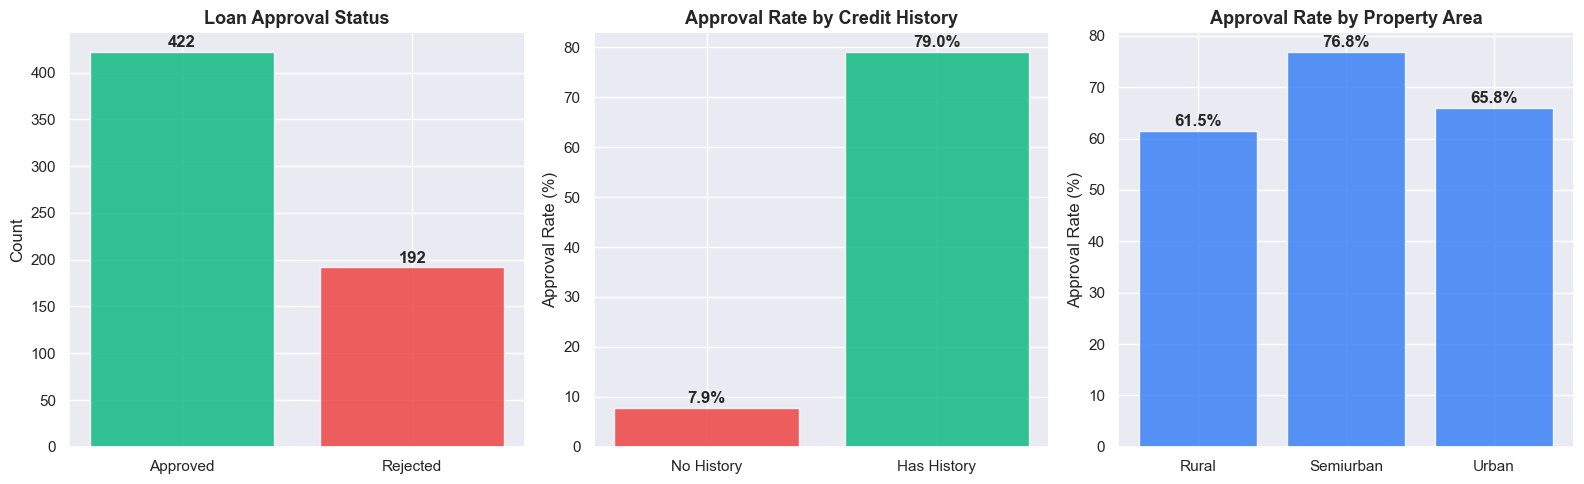

In [4]:
# Loan Status Distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Loan Status
status_counts = df['Loan_Status'].value_counts()
axes[0].bar(['Approved', 'Rejected'], status_counts.values, color=['#10b981', '#ef4444'], alpha=0.85)
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Loan Approval Status', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

# Credit History vs Approval
credit_approval = df.groupby('Credit_History')['Loan_Status'].apply(lambda x: (x == 'Y').mean() * 100)
axes[1].bar(['No History', 'Has History'], credit_approval.values, color=['#ef4444', '#10b981'], alpha=0.85)
for i, v in enumerate(credit_approval.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Approval Rate by Credit History', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Approval Rate (%)')

# Property Area vs Approval
area_approval = df.groupby('Property_Area')['Loan_Status'].apply(lambda x: (x == 'Y').mean() * 100)
axes[2].bar(area_approval.index, area_approval.values, color='#3b82f6', alpha=0.85)
for i, v in enumerate(area_approval.values):
    axes[2].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
axes[2].set_title('Approval Rate by Property Area', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Approval Rate (%)')

plt.tight_layout()
plt.savefig(f'{OUT}/loan_overview.png', dpi=150)
plt.show()

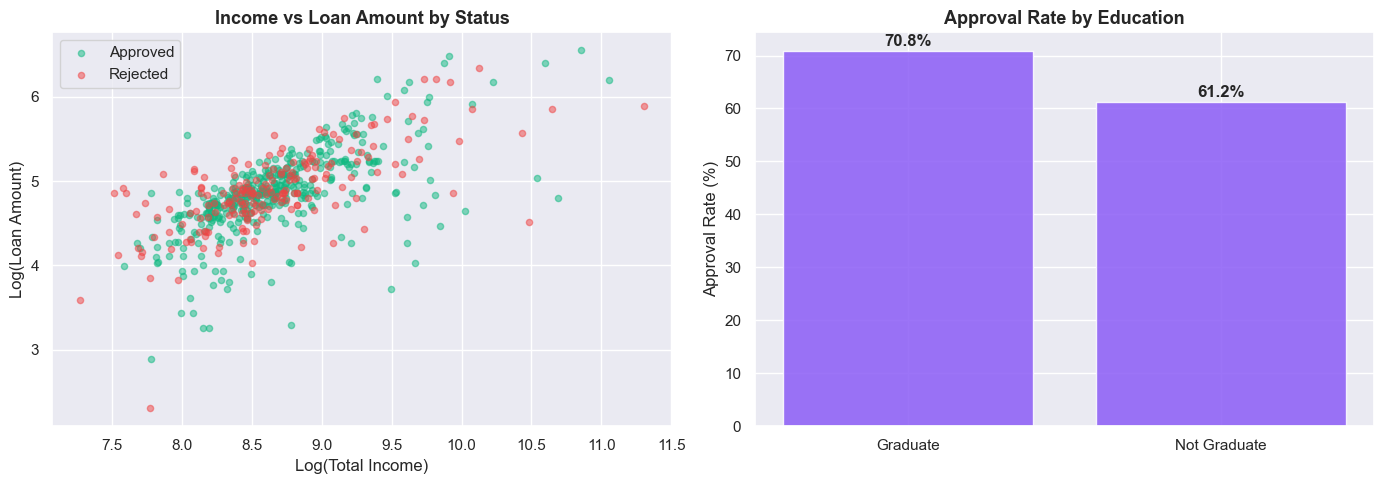

In [5]:
# Income vs Loan Amount by Status
approved = df[df['Loan_Status'] == 'Y']
rejected = df[df['Loan_Status'] == 'N']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(approved['TotalIncomeLog'], approved['LoanAmountLog'], alpha=0.5, color='#10b981', label='Approved', s=20)
axes[0].scatter(rejected['TotalIncomeLog'], rejected['LoanAmountLog'], alpha=0.5, color='#ef4444', label='Rejected', s=20)
axes[0].set_title('Income vs Loan Amount by Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Log(Total Income)')
axes[0].set_ylabel('Log(Loan Amount)')
axes[0].legend()

# Approval rate by Education
edu_approval = df.groupby('Education')['Loan_Status'].apply(lambda x: (x == 'Y').mean() * 100)
axes[1].bar(edu_approval.index, edu_approval.values, color='#8b5cf6', alpha=0.85)
for i, v in enumerate(edu_approval.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Approval Rate by Education', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Approval Rate (%)')

plt.tight_layout()
plt.savefig(f'{OUT}/income_vs_loan.png', dpi=150)
plt.show()

## 5. Model Training & Evaluation

In [6]:
# Encode categorical features
df_model = df.copy()
le = LabelEncoder()
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
            'LoanAmountLog', 'Loan_Amount_Term', 'Credit_History', 'Property_Area',
            'TotalIncomeLog']

X = df_model[features]
y = df_model['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train size : {X_train.shape[0]}')
print(f'Test size  : {X_test.shape[0]}')

Train size : 491
Test size  : 123


In [7]:
models = {
    'Logistic Regression'     : LogisticRegression(max_iter=1000),
    'Random Forest'           : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'       : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv  = cross_val_score(model, X, y, cv=5).mean()
    results[name] = {'accuracy': acc, 'cv_score': cv, 'pred': y_pred, 'model': model}
    print(f'{name}')
    print(f'  Accuracy  : {acc*100:.2f}%')
    print(f'  CV Score  : {cv*100:.2f}%')
    print()

Logistic Regression
  Accuracy  : 78.86%
  CV Score  : 80.95%

Random Forest
  Accuracy  : 77.24%
  CV Score  : 78.34%

Gradient Boosting
  Accuracy  : 76.42%
  CV Score  : 78.18%



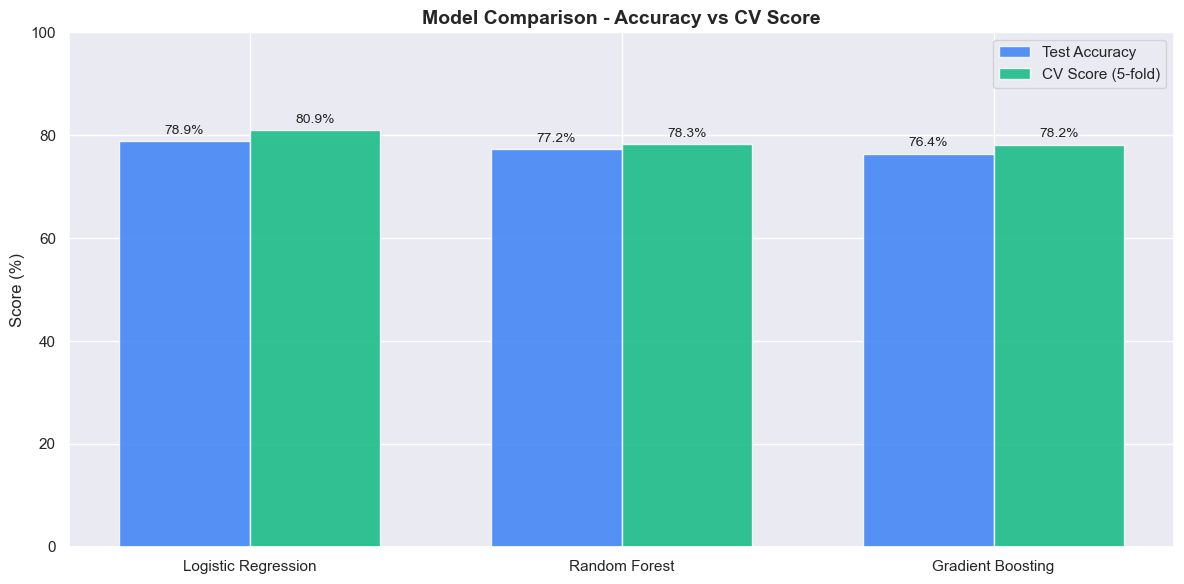

In [8]:
# Model Comparison
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] * 100 for m in model_names]
cv_scores   = [results[m]['cv_score'] * 100 for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Test Accuracy', color='#3b82f6', alpha=0.85)
bars2 = ax.bar(x + width/2, cv_scores,  width, label='CV Score (5-fold)', color='#10b981', alpha=0.85)
ax.bar_label(bars1, fmt='{:.1f}%', padding=3, fontsize=10)
ax.bar_label(bars2, fmt='{:.1f}%', padding=3, fontsize=10)
ax.set_title('Model Comparison - Accuracy vs CV Score', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 100)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT}/model_comparison.png', dpi=150)
plt.show()

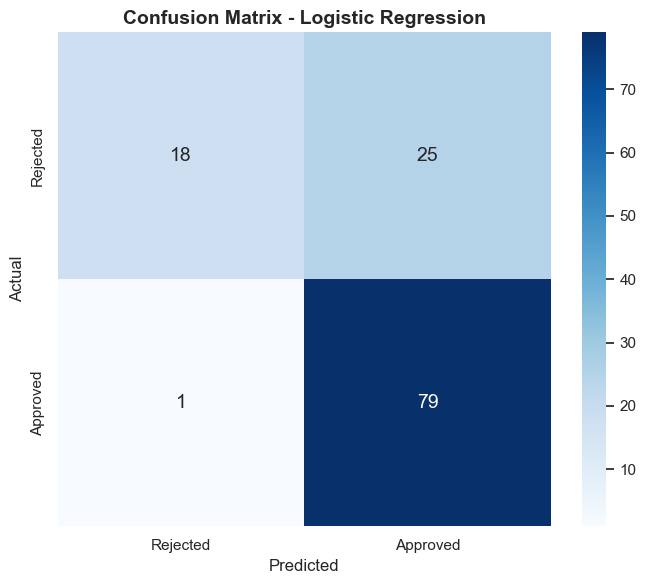

In [9]:
# Confusion Matrix - Best Model
best_name  = max(results, key=lambda x: results[x]['cv_score'])
best_pred  = results[best_name]['pred']
cm = confusion_matrix(y_test, best_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'],
            annot_kws={'size': 14})
ax.set_title(f'Confusion Matrix - {best_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(f'{OUT}/confusion_matrix.png', dpi=150)
plt.show()

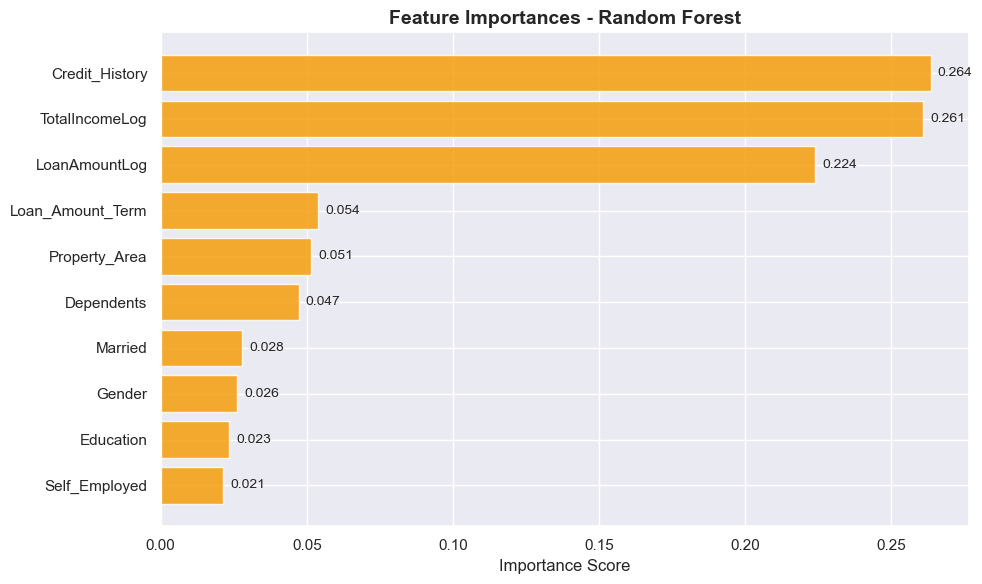

In [10]:
# Feature Importance - Random Forest
rf_model   = results['Random Forest']['model']
importance = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importance.index[::-1], importance.values[::-1], color='#f59e0b', alpha=0.85)
ax.bar_label(bars, fmt='{:.3f}', padding=5, fontsize=10)
ax.set_title('Feature Importances - Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(f'{OUT}/feature_importance.png', dpi=150)
plt.show()

## 6. Key Statistics

In [11]:
best_name = max(results, key=lambda x: results[x]['cv_score'])

print('=' * 50)
print('        LOANSENSE - KEY STATISTICS')
print('=' * 50)
print(f'  Total Applicants  : {len(df)}')
print(f'  Approval Rate     : {(df["Loan_Status"] == "Y").mean()*100:.1f}%')
print(f'  Features Used     : {len(features)}')
print(f'  Best Model        : {best_name}')
print(f'  Best Accuracy     : {results[best_name]["accuracy"]*100:.2f}%')
print(f'  Best CV Score     : {results[best_name]["cv_score"]*100:.2f}%')
print('=' * 50)

        LOANSENSE - KEY STATISTICS
  Total Applicants  : 614
  Approval Rate     : 68.7%
  Features Used     : 10
  Best Model        : Logistic Regression
  Best Accuracy     : 78.86%
  Best CV Score     : 80.95%


---
**Tools:** Python - Pandas - NumPy - Scikit-learn - Matplotlib - Seaborn  
**Author:** Berke Arda Turk